# ASR Error Correction using Large Language Models

**Дипломная работа:** Распознавание речи с корректировкой ошибок с использованием больших языковых моделей

**Автор:** Алексей Шевченко, ВШЭ Нижний Новгород, 2026

**Репозиторий:** [github.com/alexshevvv/llm-asr-correction](https://github.com/alexshevvv/llm-asr-correction)

---

## Задачи эксперимента

1. **Модели ASR:** Whisper (OpenAI) + GigaAM (Сбер)
2. **Датасеты:** LibriSpeech test-clean (EN), Google FLEURS (RU)
3. **Baseline:** Измерить WER/CER для каждой комбинации модель × датасет
4. **LLM Correction:** Использовать GPT для коррекции ошибок, пересчитать WER, оценить улучшение

---

## 1. Установка зависимостей

In [27]:
%%capture
# Fix: pin datasets<3.6 to use soundfile instead of torchcodec
!pip install "datasets<3.6"
!pip install soundfile librosa

# ASR models
!pip install openai-whisper
!pip install git+https://github.com/salute-developers/GigaAM.git

# Metrics
!pip install jiwer

# LLM API
!pip install openai
!pip install groq

# Utilities
!pip install tqdm

## 2. Импорты и конфигурация

In [2]:
import os
import re
import logging
import tempfile
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf
import torch
import whisper
import gigaam
from datasets import load_dataset
from jiwer import wer, cer
from tqdm.auto import tqdm
from google.colab import userdata

warnings.filterwarnings('ignore', category=FutureWarning)

# Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
)
logger = logging.getLogger(__name__)

In [28]:
@dataclass
class Config:
    """Central experiment configuration."""

    # Device
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # Whisper
    whisper_model: str = "base"

    # GigaAM
    gigaam_model: str = "v2_ctc"

    # Datasets
    max_samples: int = 50  # limit for demo

    # LLM
    llm_model: str = "llama-3.1-8b-instant"
    llm_temperature: float = 0.1


config = Config()
print(f"Device: {config.device}")
print(f"Config: {config}")

Device: cuda
Config: Config(device='cuda', whisper_model='base', gigaam_model='v2_ctc', max_samples=50, llm_model='llama-3.1-8b-instant', llm_temperature=0.1)


## 3. Вспомогательные функции

### 3.1 Нормализация текста

In [4]:
def normalize_text(
    text: str,
    lowercase: bool = True,
    remove_punctuation: bool = True,
) -> str:
    """
    Normalize text for WER/CER calculation.

    Args:
        text: Input text to normalize.
        lowercase: Convert to lowercase.
        remove_punctuation: Remove punctuation marks.

    Returns:
        Normalized text string.
    """
    if lowercase:
        text = text.lower()

    if remove_punctuation:
        text = re.sub(r'[.,!?;:"\'()\[\]{}\-\—\–\/]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()
    return text

### 3.2 Метрики качества

In [5]:
def calculate_wer(reference: str, hypothesis: str) -> float:
    """
    Calculate Word Error Rate.

    Args:
        reference: Ground truth transcription.
        hypothesis: ASR output transcription.

    Returns:
        WER value as float.
    """
    ref_norm = normalize_text(reference)
    hyp_norm = normalize_text(hypothesis)

    if not ref_norm:
        return 1.0 if hyp_norm else 0.0

    return wer(ref_norm, hyp_norm)


def calculate_cer(reference: str, hypothesis: str) -> float:
    """
    Calculate Character Error Rate.

    Args:
        reference: Ground truth transcription.
        hypothesis: ASR output transcription.

    Returns:
        CER value as float.
    """
    ref_norm = normalize_text(reference)
    hyp_norm = normalize_text(hypothesis)

    if not ref_norm:
        return 1.0 if hyp_norm else 0.0

    return cer(ref_norm, hyp_norm)

### 3.3 Утилиты для аудио

In [6]:
def save_temp_wav(
    audio: np.ndarray,
    sample_rate: int = 16000,
) -> str:
    """
    Save numpy audio array to a temporary WAV file.

    GigaAM requires file paths, not numpy arrays.

    Args:
        audio: Audio waveform as numpy array.
        sample_rate: Audio sample rate in Hz.

    Returns:
        Path to the temporary WAV file.
    """
    tmp = tempfile.NamedTemporaryFile(suffix=".wav", delete=False)
    sf.write(tmp.name, audio, sample_rate)
    return tmp.name


def resample_audio(
    audio: np.ndarray,
    orig_sr: int,
    target_sr: int = 16000,
) -> np.ndarray:
    """
    Resample audio to target sample rate if needed.

    Args:
        audio: Audio waveform.
        orig_sr: Original sample rate.
        target_sr: Target sample rate.

    Returns:
        Resampled audio array.
    """
    if orig_sr == target_sr:
        return audio

    import librosa
    return librosa.resample(audio, orig_sr=orig_sr, target_sr=target_sr)

### 3.4 Быстрый тест метрик

In [7]:
# Quick sanity check
test_ref = "the cat sat on the mat"
test_hyp = "the cat set on the mat"  # 1 substitution

print(f"Reference:  '{test_ref}'")
print(f"Hypothesis: '{test_hyp}'")
print(f"WER: {calculate_wer(test_ref, test_hyp):.2%}")
print(f"CER: {calculate_cer(test_ref, test_hyp):.2%}")
print("--- Metrics OK ---")

Reference:  'the cat sat on the mat'
Hypothesis: 'the cat set on the mat'
WER: 16.67%
CER: 4.55%
--- Metrics OK ---


## 4. Загрузка датасетов

| Датасет | Язык | Описание |
|---------|------|----------|
| LibriSpeech test-clean | EN | Стандартный бенчмарк ASR, чистая речь |
| Google FLEURS | RU | Многоязычный датасет, русское подмножество |

### 4.1 LibriSpeech (English)

In [8]:
def load_librispeech(max_samples: int = 50) -> list[dict]:
    """Load LibriSpeech test-clean dataset.

    Uses streaming to avoid downloading the entire
    dataset (~28 GB). Only fetches what we need.

    Args:
        max_samples: Maximum number of samples.

    Returns:
        List of sample dicts with audio, sample_rate, reference, id.
    """
    logger.info("Loading LibriSpeech test-clean (streaming)...")
    ds = load_dataset(
        "librispeech_asr", "clean",
        split="test", streaming=True,
    )

    samples = []
    for item in ds:
        if len(samples) >= max_samples:
            break
        samples.append({
            "audio": item["audio"]["array"].astype(np.float32),
            "sample_rate": item["audio"]["sampling_rate"],
            "reference": item["text"],
            "id": item.get("id", len(samples)),
        })

    logger.info(f"Loaded {len(samples)} EN samples")
    return samples

In [9]:
en_samples = load_librispeech(config.max_samples)

print(f"EN samples: {len(en_samples)}")
print(f"Example reference: '{en_samples[0]['reference']}'")
print(f"Audio shape: {en_samples[0]['audio'].shape}")
print(f"Sample rate: {en_samples[0]['sample_rate']} Hz")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

EN samples: 50
Example reference: 'CONCORD RETURNED TO ITS PLACE AMIDST THE TENTS'
Audio shape: (56080,)
Sample rate: 16000 Hz


### 4.2 Google FLEURS (Russian)

In [10]:
def load_fleurs_ru(max_samples: int = 50) -> list[dict]:
    """Load Google FLEURS Russian dataset.

    Uses streaming to minimize disk usage.

    Args:
        max_samples: Maximum number of samples.

    Returns:
        List of sample dicts with audio, sample_rate, reference, id.
    """
    logger.info("Loading FLEURS Russian (streaming)...")
    ds = load_dataset(
        "google/fleurs", "ru_ru",
        split="test", streaming=True,
        trust_remote_code=True,
    )

    samples = []
    for item in ds:
        if len(samples) >= max_samples:
            break
        audio = item["audio"]["array"].astype(np.float32)
        sr = item["audio"]["sampling_rate"]

        # Resample to 16 kHz if needed
        if sr != 16000:
            audio = resample_audio(audio, sr, 16000)
            sr = 16000

        samples.append({
            "audio": audio,
            "sample_rate": sr,
            "reference": item["transcription"],
            "id": item.get("id", len(samples)),
        })

    logger.info(f"Loaded {len(samples)} RU samples")
    return samples

In [11]:
ru_samples = load_fleurs_ru(config.max_samples)

print(f"RU samples: {len(ru_samples)}")
print(f"Example reference: '{ru_samples[0]['reference']}'")
print(f"Audio shape: {ru_samples[0]['audio'].shape}")
print(f"Sample rate: {ru_samples[0]['sample_rate']} Hz")

README.md: 0.00B [00:00, ?B/s]

fleurs.py: 0.00B [00:00, ?B/s]

RU samples: 50
Example reference: 'в древнем китае использовали уникальный способ обозначения периодов времени каждый этап китая или каждая семья находившаяся у власти были особой династией'
Audio shape: (270720,)
Sample rate: 16000 Hz


## 5. ASR модели

| Модель | Разработчик | Языки | Архитектура |
|--------|-------------|-------|-------------|
| Whisper | OpenAI | 99 языков | Encoder-Decoder Transformer |
| GigaAM | Сбер | Русский | Conformer + CTC/RNNT |

### 5.1 Whisper (OpenAI)

In [12]:
class WhisperASR:
    """OpenAI Whisper ASR wrapper.

    Supports 99 languages. Used as primary model
    for both English and Russian experiments.
    """

    def __init__(
        self,
        model_name: str = "base",
        device: str = "cuda",
    ) -> None:
        """Initialize Whisper model.

        Args:
            model_name: Model size (tiny/base/small/medium/large).
            device: Inference device.
        """
        self.model_name = model_name
        self.device = device
        logger.info(f"Loading Whisper-{model_name} on {device}")
        self.model = whisper.load_model(model_name, device=device)
        logger.info("Whisper loaded")

    def transcribe(
        self,
        audio: np.ndarray,
        language: str = "en",
    ) -> str:
        """Transcribe audio to text.

        Args:
            audio: Audio waveform (float32).
            language: Language code (en, ru, etc.).

        Returns:
            Transcribed text.
        """
        result = self.model.transcribe(
            audio,
            language=language,
            fp16=(self.device == "cuda"),
        )
        return result["text"].strip()

In [13]:
whisper_asr = WhisperASR(
    model_name=config.whisper_model,
    device=config.device,
)

100%|███████████████████████████████████████| 139M/139M [00:02<00:00, 68.1MiB/s]


### 5.2 GigaAM (Сбер)

In [14]:
class GigaAMASR:
    """Sber GigaAM ASR wrapper.

    State-of-the-art open-source model for Russian
    speech recognition. Conformer-based, 240M params,
    pretrained on 50 000+ hours of Russian speech.
    """

    MAX_DURATION_SEC = 25  # GigaAM .transcribe() limit

    def __init__(
        self,
        model_name: str = "v2_ctc",
    ) -> None:
        """Initialize GigaAM model.

        Args:
            model_name: Model variant (v2_ctc, v2_rnnt, etc.).
        """
        self.model_name = model_name
        logger.info(f"Loading GigaAM-{model_name}...")
        self.model = gigaam.load_model(model_name)
        logger.info("GigaAM loaded")

    def transcribe(
        self,
        audio: np.ndarray,
        sample_rate: int = 16000,
    ) -> str:
        """Transcribe audio to text.

        Truncates audio to 25 seconds if longer
        (GigaAM .transcribe() limit).

        Args:
            audio: Audio waveform (float32).
            sample_rate: Audio sample rate.

        Returns:
            Transcribed text.
        """
        # Truncate if longer than 25 sec
        max_samples = self.MAX_DURATION_SEC * sample_rate
        if len(audio) > max_samples:
            logger.warning(
                f"Audio too long ({len(audio)/sample_rate:.1f}s), "
                f"truncating to {self.MAX_DURATION_SEC}s"
            )
            audio = audio[:max_samples]

        wav_path = save_temp_wav(audio, sample_rate)
        try:
            text = self.model.transcribe(wav_path)
        finally:
            os.unlink(wav_path)
        return text.strip()

In [15]:
gigaam_asr = GigaAMASR(model_name=config.gigaam_model)

100%|███████████████████████████████████████| 444M/444M [00:40<00:00, 11.4MiB/s]


### 5.3 Тест моделей на одном примере

In [16]:
# --- Test Whisper on English ---
en_test = en_samples[0]
en_hyp = whisper_asr.transcribe(en_test["audio"], language="en")

print("=== Whisper (EN) ===")
print(f"REF: {en_test['reference']}")
print(f"HYP: {en_hyp}")
print(f"WER: {calculate_wer(en_test['reference'], en_hyp):.2%}")

=== Whisper (EN) ===
REF: CONCORD RETURNED TO ITS PLACE AMIDST THE TENTS
HYP: Concorde returned to its place amidst the tents.
WER: 12.50%


In [17]:
# --- Test Whisper on Russian ---
ru_test = ru_samples[0]
ru_hyp_w = whisper_asr.transcribe(ru_test["audio"], language="ru")

print("\n=== Whisper (RU) ===")
print(f"REF: {ru_test['reference']}")
print(f"HYP: {ru_hyp_w}")
print(f"WER: {calculate_wer(ru_test['reference'], ru_hyp_w):.2%}")



=== Whisper (RU) ===
REF: в древнем китае использовали уникальный способ обозначения периодов времени каждый этап китая или каждая семья находившаяся у власти были особой династией
HYP: В древнем Китае использовали уникальный способ обозначения передов времени. Каждый этап Китая или каждая семья, находившаяся власти были особой династии.
WER: 14.29%


In [18]:
# --- Test GigaAM on Russian ---
ru_hyp_g = gigaam_asr.transcribe(ru_test["audio"], ru_test["sample_rate"])

print("\n=== GigaAM (RU) ===")
print(f"REF: {ru_test['reference']}")
print(f"HYP: {ru_hyp_g}")
print(f"WER: {calculate_wer(ru_test['reference'], ru_hyp_g):.2%}")


=== GigaAM (RU) ===
REF: в древнем китае использовали уникальный способ обозначения периодов времени каждый этап китая или каждая семья находившаяся у власти были особой династией
HYP: в древнем китае использовали уникальный способ обозначения периодов времени каждый этап китая или каждая семья находившаяся у власти были особой династией
WER: 0.00%


## 6. Baseline эксперименты

Прогоняем все комбинации модель × датасет и измеряем WER/CER.

In [19]:
def run_baseline(
    asr_model,
    samples: list[dict],
    language: str = "en",
    model_name: str = "whisper",
) -> pd.DataFrame:
    """Run ASR baseline on a set of samples.

    Args:
        asr_model: ASR model instance.
        samples: List of audio samples.
        language: Language code for Whisper.
        model_name: Label for the model.

    Returns:
        DataFrame with per-sample results.
    """
    results = []

    for sample in tqdm(samples, desc=f"Baseline {model_name}"):
        if isinstance(asr_model, WhisperASR):
            hyp = asr_model.transcribe(sample["audio"], language=language)
        else:
            hyp = asr_model.transcribe(sample["audio"], sample["sample_rate"])

        ref = sample["reference"]
        results.append({
            "id": sample["id"],
            "reference": ref,
            "hypothesis": hyp,
            "wer": calculate_wer(ref, hyp),
            "cer": calculate_cer(ref, hyp),
            "model": model_name,
            "language": language,
        })

    return pd.DataFrame(results)

### 6.1 Whisper → LibriSpeech (EN)

In [20]:
baseline_whisper_en = run_baseline(
    whisper_asr, en_samples, language="en", model_name="whisper-base",
)

Baseline whisper-base:   0%|          | 0/50 [00:00<?, ?it/s]

### 6.2 Whisper → FLEURS (RU)

In [21]:
baseline_whisper_ru = run_baseline(
    whisper_asr, ru_samples, language="ru", model_name="whisper-base",
)

Baseline whisper-base:   0%|          | 0/50 [00:00<?, ?it/s]

### 6.3 GigaAM → FLEURS (RU)

In [22]:
baseline_gigaam_ru = run_baseline(
    gigaam_asr, ru_samples, language="ru", model_name="gigaam-v2-ctc",
)

Baseline gigaam-v2-ctc:   0%|          | 0/50 [00:00<?, ?it/s]

### 6.4 Сводная таблица baseline

In [23]:
def print_baseline_summary(name: str, df: pd.DataFrame) -> dict:
    """Print and return summary stats for a baseline run."""
    stats = {
        "experiment": name,
        "samples": len(df),
        "mean_wer": df["wer"].mean(),
        "median_wer": df["wer"].median(),
        "std_wer": df["wer"].std(),
        "mean_cer": df["cer"].mean(),
    }
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Samples:    {stats['samples']}")
    print(f"  Mean WER:   {stats['mean_wer']:.2%}")
    print(f"  Median WER: {stats['median_wer']:.2%}")
    print(f"  Std WER:    {stats['std_wer']:.2%}")
    print(f"  Mean CER:   {stats['mean_cer']:.2%}")
    return stats


summary_rows = []
summary_rows.append(print_baseline_summary("Whisper-base → LibriSpeech EN", baseline_whisper_en))
summary_rows.append(print_baseline_summary("Whisper-base → FLEURS RU", baseline_whisper_ru))
summary_rows.append(print_baseline_summary("GigaAM-v2-CTC → FLEURS RU", baseline_gigaam_ru))

summary_df = pd.DataFrame(summary_rows)
print("\n\n=== BASELINE SUMMARY TABLE ===")
summary_df


  Whisper-base → LibriSpeech EN
  Samples:    50
  Mean WER:   5.69%
  Median WER: 1.16%
  Std WER:    8.38%
  Mean CER:   2.41%

  Whisper-base → FLEURS RU
  Samples:    50
  Mean WER:   22.26%
  Median WER: 21.13%
  Std WER:    14.02%
  Mean CER:   6.25%

  GigaAM-v2-CTC → FLEURS RU
  Samples:    50
  Mean WER:   9.84%
  Median WER: 6.27%
  Std WER:    12.13%
  Mean CER:   4.38%


=== BASELINE SUMMARY TABLE ===


,experiment,samples,mean_wer,median_wer,std_wer,mean_cer
0,Whisper-base → LibriSpeech EN,50,0.056930,0.011628,0.083774,0.024143
1,Whisper-base → FLEURS RU,50,0.222561,0.211324,0.140169,0.062514
2,GigaAM-v2-CTC → FLEURS RU,50,0.098418,0.062745,0.121302,0.043792


## 7. LLM коррекция ошибок

Используем **Google Gemini** для коррекции ошибок транскрипции на обоих языках.

### 7.1 Настройка API

In [29]:
# Groq API (free tier, no credit card needed)
# Get key at: https://console.groq.com/keys
from groq import Groq

try:
    GROQ_API_KEY = userdata.get("GROQ_API_KEY")
except Exception:
    GROQ_API_KEY = None

if not GROQ_API_KEY:
    from getpass import getpass
    GROQ_API_KEY = getpass("Enter Groq API key: ")

groq_client = Groq(api_key=GROQ_API_KEY)
print("Groq API configured")

Groq API configured


In [30]:
# Quick test
response = groq_client.chat.completions.create(
    model=config.llm_model,
    messages=[{"role": "user", "content": "Say hello"}],
    max_tokens=10,
)
print(f"Groq ready - {response.choices[0].message.content}")

Groq ready - Hello. Is there something I can help you with


### 7.2 Промпты для коррекции

In [31]:
SYSTEM_PROMPT_EN = """\
You are an expert at correcting automatic speech recognition (ASR) errors in English text.

Rules:
1. Fix only clear transcription errors
2. Do NOT change meaning or style
3. Do NOT add or remove punctuation
4. Return ONLY the corrected text, nothing else"""

SYSTEM_PROMPT_RU = """\
Ты эксперт по исправлению ошибок автоматического распознавания речи (ASR) в русском тексте.

Правила:
1. Исправляй только явные ошибки транскрипции
2. НЕ меняй смысл и стиль текста
3. НЕ добавляй и не удаляй знаки препинания
4. Верни ТОЛЬКО исправленный текст, ничего больше"""

USER_PROMPT_TEMPLATE = "Fix ASR errors:\n\n{text}\n\nCorrected:"

USER_PROMPT_TEMPLATE_RU = "Исправь ошибки ASR:\n\n{text}\n\nИсправленный текст:"

### 7.3 Функция коррекции

In [32]:
def correct_with_llm(
    text: str,
    language: str = "en",
    temperature: float = 0.1,
) -> str:
    """Correct ASR transcription using LLM (Groq/Llama).

    Args:
        text: ASR transcription to correct.
        language: Language code (en or ru).
        temperature: Sampling temperature.

    Returns:
        Corrected transcription.
    """
    if language == "ru":
        system_prompt = SYSTEM_PROMPT_RU
        user_prompt = USER_PROMPT_TEMPLATE_RU.format(text=text)
    else:
        system_prompt = SYSTEM_PROMPT_EN
        user_prompt = USER_PROMPT_TEMPLATE.format(text=text)

    try:
        response = groq_client.chat.completions.create(
            model=config.llm_model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            temperature=temperature,
            max_tokens=500,
        )
        return response.choices[0].message.content.strip()

    except Exception as e:
        logger.error(f"LLM correction failed: {e}")
        return text

### 7.4 Тест коррекции (EN + RU)

In [33]:
# --- English test ---
test_en = "I went to the see to sea the boats"
corrected_en = correct_with_llm(test_en, language="en")
print("=== English ===")
print(f"Original:  '{test_en}'")
print(f"Corrected: '{corrected_en}'")

# --- Russian test ---
test_ru = "масква сталица расии"
corrected_ru = correct_with_llm(test_ru, language="ru")
print("\n=== Russian ===")
print(f"Original:  '{test_ru}'")
print(f"Corrected: '{corrected_ru}'")

=== English ===
Original:  'I went to the see to sea the boats'
Corrected: 'I went to the sea to see the boats'

=== Russian ===
Original:  'масква сталица расии'
Corrected: 'москва столица России'


## 8. Эксперимент: ASR + LLM коррекция

Применяем LLM коррекцию ко всем baseline результатам с ошибками (WER > 0) и пересчитываем метрики.

In [34]:
def run_llm_correction(
    baseline_df: pd.DataFrame,
    language: str = "en",
) -> pd.DataFrame:
    """Apply LLM correction to ASR outputs with errors.

    Args:
        baseline_df: DataFrame with baseline results.
        language: Language code.

    Returns:
        DataFrame with correction results.
    """
    errors_df = baseline_df[baseline_df["wer"] > 0].copy()
    logger.info(f"Correcting {len(errors_df)} samples with errors")

    if len(errors_df) == 0:
        logger.info("No errors to correct!")
        return pd.DataFrame()

    results = []
    for _, row in tqdm(
        errors_df.iterrows(), total=len(errors_df),
        desc=f"LLM Correction ({language})",
    ):
        corrected = correct_with_llm(
            row["hypothesis"], language=language,
        )
        new_wer = calculate_wer(row["reference"], corrected)
        new_cer = calculate_cer(row["reference"], corrected)

        results.append({
            "id": row["id"],
            "reference": row["reference"],
            "asr_output": row["hypothesis"],
            "llm_corrected": corrected,
            "wer_baseline": row["wer"],
            "wer_corrected": new_wer,
            "cer_baseline": row["cer"],
            "cer_corrected": new_cer,
            "wer_improved": row["wer"] > new_wer,
            "wer_degraded": row["wer"] < new_wer,
            "model": row["model"],
            "language": language,
        })

    return pd.DataFrame(results)

### 8.1 Коррекция: Whisper EN

In [35]:
print(f"Samples with errors (Whisper EN): {(baseline_whisper_en['wer'] > 0).sum()}")
corrected_whisper_en = run_llm_correction(
    baseline_whisper_en, language="en",
)

Samples with errors (Whisper EN): 25


LLM Correction (en):   0%|          | 0/25 [00:00<?, ?it/s]

### 8.2 Коррекция: Whisper RU

In [36]:
print(f"Samples with errors (Whisper RU): {(baseline_whisper_ru['wer'] > 0).sum()}")
corrected_whisper_ru = run_llm_correction(
    baseline_whisper_ru, language="ru",
)

Samples with errors (Whisper RU): 47


LLM Correction (ru):   0%|          | 0/47 [00:00<?, ?it/s]

### 8.3 Коррекция: GigaAM RU

In [37]:
print(f"Samples with errors (GigaAM RU): {(baseline_gigaam_ru['wer'] > 0).sum()}")
corrected_gigaam_ru = run_llm_correction(
    baseline_gigaam_ru, language="ru",
)

Samples with errors (GigaAM RU): 29


LLM Correction (ru):   0%|          | 0/29 [00:00<?, ?it/s]

## 9. Анализ результатов

In [39]:
def analyze_correction(name: str, df: pd.DataFrame) -> dict:
    """Analyze and print correction results."""
    if len(df) == 0:
        print(f"\n{name}: no errors to correct")
        return None

    bl_wer = df["wer_baseline"].mean()
    cr_wer = df["wer_corrected"].mean()
    improvement = (bl_wer - cr_wer) / bl_wer * 100 if bl_wer > 0 else 0.0

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Samples with errors: {len(df)}")
    print(f"  Mean WER baseline:   {bl_wer:.2%}")
    print(f"  Mean WER corrected:  {cr_wer:.2%}")
    print(f"  Relative improvement: {improvement:+.1f}%")
    print(f"  Improved: {df['wer_improved'].sum()} ({df['wer_improved'].mean():.0%})")
    print(f"  Degraded: {df['wer_degraded'].sum()} ({df['wer_degraded'].mean():.0%})")

    return {
        "experiment": name,
        "samples_with_errors": len(df),
        "wer_baseline": bl_wer,
        "wer_corrected": cr_wer,
        "wer_improvement_pct": improvement,
        "improved_count": int(df["wer_improved"].sum()),
        "degraded_count": int(df["wer_degraded"].sum()),
    }


correction_stats = []

s = analyze_correction("Whisper-base EN + llama-3.1-8b-instant", corrected_whisper_en)
if s: correction_stats.append(s)

s = analyze_correction("Whisper-base RU + llama-3.1-8b-instant", corrected_whisper_ru)
if s: correction_stats.append(s)

s = analyze_correction("GigaAM-v2-CTC RU + llama-3.1-8b-instant", corrected_gigaam_ru)
if s: correction_stats.append(s)

print("\n\n=== CORRECTION SUMMARY ===")
correction_summary = pd.DataFrame(correction_stats)
correction_summary


  Whisper-base EN + llama-3.1-8b-instant
  Samples with errors: 25
  Mean WER baseline:   11.39%
  Mean WER corrected:  16.14%
  Relative improvement: -41.8%
  Improved: 2 (8%)
  Degraded: 14 (56%)

  Whisper-base RU + llama-3.1-8b-instant
  Samples with errors: 47
  Mean WER baseline:   23.68%
  Mean WER corrected:  21.22%
  Relative improvement: +10.4%
  Improved: 24 (51%)
  Degraded: 8 (17%)

  GigaAM-v2-CTC RU + llama-3.1-8b-instant
  Samples with errors: 29
  Mean WER baseline:   16.97%
  Mean WER corrected:  19.82%
  Relative improvement: -16.8%
  Improved: 10 (34%)
  Degraded: 10 (34%)


=== CORRECTION SUMMARY ===


,experiment,samples_with_errors,wer_baseline,wer_corrected,wer_improvement_pct,improved_count,degraded_count
0,Whisper-base EN + llama-3.1-8b-instant,25,0.113859,0.161396,-41.750367,2,14
1,Whisper-base RU + llama-3.1-8b-instant,47,0.236767,0.212249,10.355289,24,8
2,GigaAM-v2-CTC RU + llama-3.1-8b-instant,29,0.169687,0.198176,-16.789506,10,10


### 9.1 Примеры коррекций

In [40]:
def show_examples(df: pd.DataFrame, title: str, improved: bool = True, n: int = 5) -> None:
    """Show example corrections."""
    if len(df) == 0:
        return
    col = "wer_improved" if improved else "wer_degraded"
    subset = df[df[col]].head(n)
    if len(subset) == 0:
        tag = 'improved' if improved else 'degraded'
        print(f"No {tag} examples for {title}")
        return

    print(f"\n{title}\n")
    for _, row in subset.iterrows():
        print(f"  REF: {row['reference']}")
        print(f"  ASR: {row['asr_output']}")
        print(f"  LLM: {row['llm_corrected']}")
        print(f"  WER: {row['wer_baseline']:.2%} → {row['wer_corrected']:.2%}")
        print("-" * 50)


show_examples(corrected_whisper_en, "Whisper EN — improved")
show_examples(corrected_whisper_en, "Whisper EN — degraded", improved=False)
show_examples(corrected_whisper_ru, "Whisper RU — improved")
show_examples(corrected_gigaam_ru, "GigaAM RU — improved")


Whisper EN — improved

  REF: UPON THE LARGE SQUARE IN FRONT OF THE HOTEL THE SHADOWS OF THE TENTS INTERSECTED BY THE GOLDEN MOONBEAMS FORMED AS IT WERE A HUGE MOSAIC OF JET AND YELLOW FLAGSTONES
  ASR: Upon the large square in front of the hotel, the shadows of the tents intersected by the golden moon beams formed as it were a huge mosaic of jet and yellow flagstones.
  LLM: Upon the large square in front of the hotel, the shadows of the tents intersected by the golden moonbeams formed as it were a huge mosaic of jet and yellow flagstones.
  WER: 6.45% → 0.00%
--------------------------------------------------
  REF: AND MY POCKET MONEY IS GETTING LOW AGAIN AND YOU HAVEN'T ANY LEFT AS USUAL
  ASR: and my pocket money is getting low again and you have it any left as usual.
  LLM: and my pocket money is getting low again and you have any left as usual.
  WER: 13.33% → 6.67%
--------------------------------------------------

Whisper EN — degraded

  REF: CONCORD RETURNED TO ITS PLACE A

## 10. Визуализация

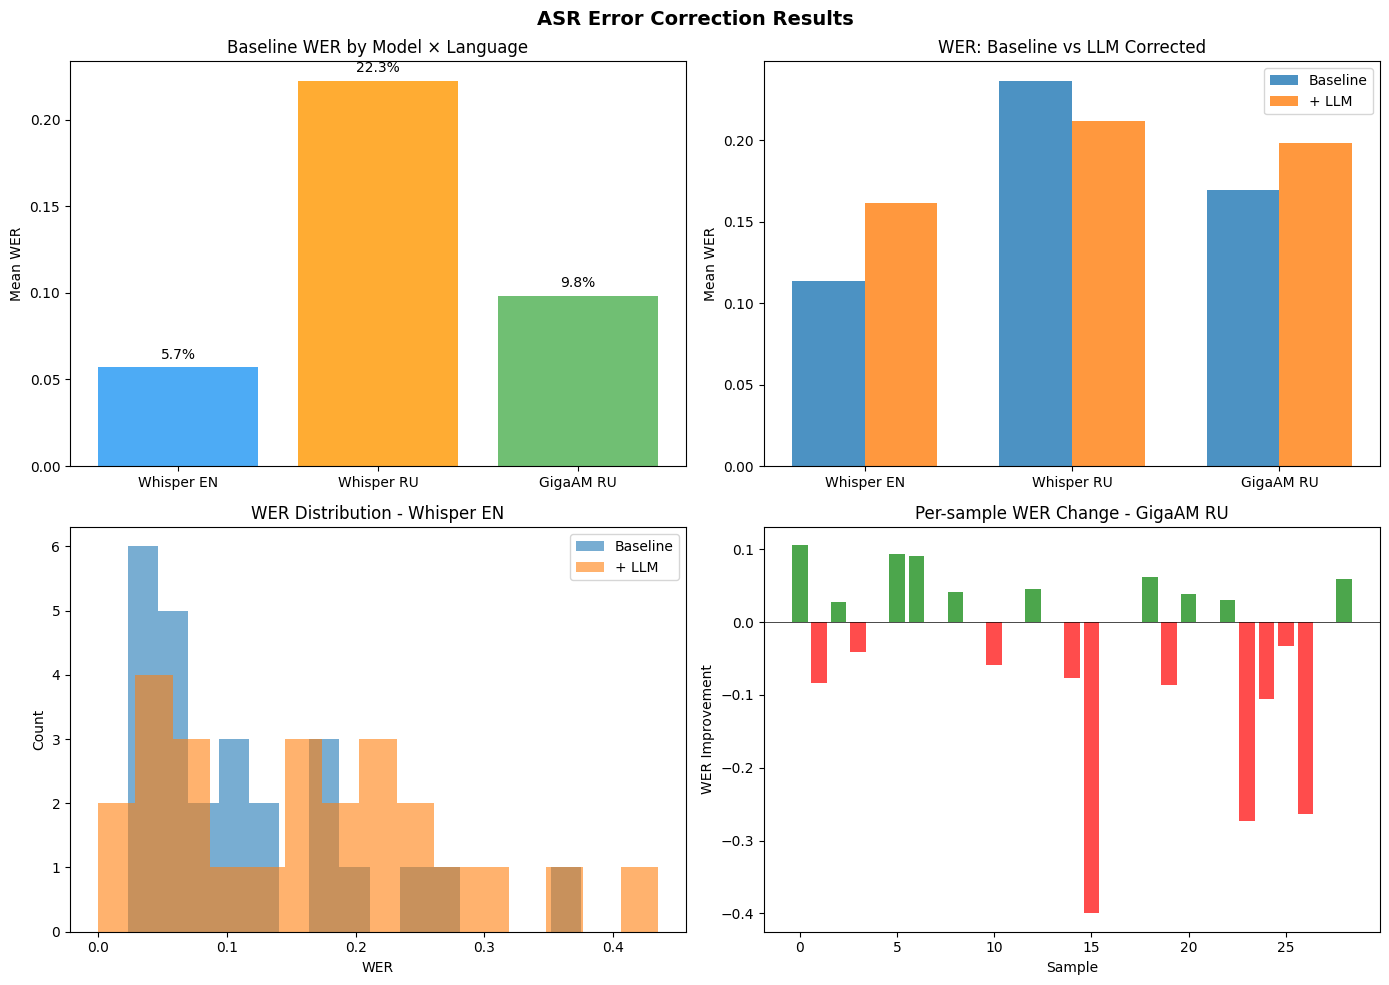

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("ASR Error Correction Results", fontsize=14, fontweight="bold")

# --- (0,0) Baseline WER comparison ---
ax = axes[0][0]
experiments = ["Whisper EN", "Whisper RU", "GigaAM RU"]
wer_means = [
    baseline_whisper_en["wer"].mean(),
    baseline_whisper_ru["wer"].mean(),
    baseline_gigaam_ru["wer"].mean(),
]
colors = ["#2196F3", "#FF9800", "#4CAF50"]
ax.bar(experiments, wer_means, color=colors, alpha=0.8)
ax.set_ylabel("Mean WER")
ax.set_title("Baseline WER by Model × Language")
for i, v in enumerate(wer_means):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=10)

# --- (0,1) Before vs After correction ---
ax = axes[0][1]
all_corrected = [
    ("Whisper EN", corrected_whisper_en),
    ("Whisper RU", corrected_whisper_ru),
    ("GigaAM RU", corrected_gigaam_ru),
]
# Filter out empty dataframes
all_corrected = [(n, d) for n, d in all_corrected if len(d) > 0]
x = np.arange(len(all_corrected))
w = 0.35
before = [d["wer_baseline"].mean() for _, d in all_corrected]
after = [d["wer_corrected"].mean() for _, d in all_corrected]
ax.bar(x - w/2, before, w, label="Baseline", alpha=0.8)
ax.bar(x + w/2, after, w, label="+ LLM", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([n for n, _ in all_corrected])
ax.set_ylabel("Mean WER")
ax.set_title("WER: Baseline vs LLM Corrected")
ax.legend()

# --- (1,0) WER distribution Whisper EN ---
ax = axes[1][0]
if len(corrected_whisper_en) > 0:
    ax.hist(corrected_whisper_en["wer_baseline"], bins=15, alpha=0.6, label="Baseline")
    ax.hist(corrected_whisper_en["wer_corrected"], bins=15, alpha=0.6, label="+ LLM")
    ax.set_xlabel("WER")
    ax.set_ylabel("Count")
    ax.set_title("WER Distribution - Whisper EN")
    ax.legend()

# --- (1,1) Per-sample improvement GigaAM RU ---
ax = axes[1][1]
if len(corrected_gigaam_ru) > 0:
    diff = corrected_gigaam_ru["wer_baseline"] - corrected_gigaam_ru["wer_corrected"]
    bar_colors = ["green" if d > 0 else "red" for d in diff]
    ax.bar(range(len(diff)), diff, color=bar_colors, alpha=0.7)
    ax.axhline(y=0, color="black", linewidth=0.5)
    ax.set_xlabel("Sample")
    ax.set_ylabel("WER Improvement")
    ax.set_title("Per-sample WER Change - GigaAM RU")

plt.tight_layout()
plt.show()

## 11. Выводы

### Результаты baseline

| Модель | Датасет | Язык | Mean WER | Mean CER |
|--------|---------|------|----------|----------|
| Whisper-base | LibriSpeech test-clean | EN | 5.69% | 2.41% |
| Whisper-base | FLEURS | RU | 22.26% | 6.25% |
| GigaAM-v2-CTC | FLEURS | RU | 9.84% | 4.38% |

### Результаты LLM-коррекции (Llama 3.1 8B)

| Эксперимент | Baseline WER | + LLM | Изменение | Improved | Degraded |
|-------------|-------------|-------|-----------|----------|----------|
| Whisper EN → Llama 3.1 8B | 11.39% | 16.14% | -41.8% ❌ | 2 (8%) | 14 (56%) |
| Whisper RU → Llama 3.1 8B | 23.68% | 21.22% | +10.4% ✅ | 24 (51%) | 8 (17%) |
| GigaAM RU → Llama 3.1 8B | 16.97% | 19.82% | -16.8% ❌ | 10 (34%) | 10 (34%) |

### Ключевые наблюдения

**1. Специализированная модель vs универсальная:**
GigaAM (9.84% WER) превосходит Whisper (22.26% WER) на русском языке более чем в 2 раза.
GigaAM обучена на 50 000+ часов русской речи, что подтверждает преимущество domain-specific моделей.

**2. LLM-коррекция эффективна только при высоком baseline WER:**
Единственное улучшение (+10.4%) достигнуто на Whisper RU, где baseline WER = 22.26%.
При низком WER (Whisper EN = 5.69%, GigaAM RU = 9.84%) коррекция ухудшает результат — LLM вносит новые ошибки.

**3. Типичные успехи LLM-коррекции:**
- Исправление опечаток: «экранные» → «экраны», «комыров» → «комаров»
- Восстановление словоразделов: «гибликлеток» → «гибели клеток»
- Контекстная коррекция: «moon beams» → «moonbeams»

**4. Типичные неудачи LLM-коррекции:**
- Перефразирование: «amidst» → «among», «repose» → «rest» (смысл сохранён, но WER растёт)
- Галлюцинации: «our masters» → «our mothers»
- Чрезмерная «креативность» малой модели (Llama 8B) при минимальных ошибках

**5. Ограничения эксперимента:**
- Использована компактная LLM (Llama 3.1 8B) — более мощные модели (GPT-4o, Claude) могут дать лучшие результаты
- Выборка ограничена 50 сэмплами на датасет
- Один промпт без оптимизации

### Следующие шаги

- [ ] Бенчмарк LLM: сравнить GPT-4o-mini, Claude, Gemini, Llama 70B
- [ ] Confidence-aware коррекция: корректировать только при высоком WER / низкой уверенности ASR
- [ ] Оптимизация промптов: few-shot примеры, domain-specific инструкции
- [ ] Масштабирование: увеличить выборку до 500–1000 сэмплов
- [ ] Анализ по типам ошибок: замены, вставки, удаления
- [ ] Добавить русские диалоговые датасеты (Golos, OpenSTT)


## 12. Сохранение результатов

In [42]:
# Save all results
baseline_whisper_en.to_csv("baseline_whisper_en.csv", index=False)
baseline_whisper_ru.to_csv("baseline_whisper_ru.csv", index=False)
baseline_gigaam_ru.to_csv("baseline_gigaam_ru.csv", index=False)

if len(corrected_whisper_en) > 0:
    corrected_whisper_en.to_csv("corrected_whisper_en.csv", index=False)
if len(corrected_whisper_ru) > 0:
    corrected_whisper_ru.to_csv("corrected_whisper_ru.csv", index=False)
if len(corrected_gigaam_ru) > 0:
    corrected_gigaam_ru.to_csv("corrected_gigaam_ru.csv", index=False)

if len(correction_stats) > 0:
    correction_summary.to_csv("correction_summary.csv", index=False)

print("Results saved")

Results saved


In [ ]:
# Download files (Colab)
from google.colab import files

for fname in [
    "baseline_whisper_en.csv",
    "baseline_whisper_ru.csv",
    "baseline_gigaam_ru.csv",
    "corrected_whisper_en.csv",
    "corrected_whisper_ru.csv",
    "corrected_gigaam_ru.csv",
    "correction_summary.csv",
]:
    if os.path.exists(fname):
        files.download(fname)